In [53]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "font.size": 12,
    })

import pandas as pd
from scipy.interpolate import interp1d

# load EOS
m_val, r_val, l_val = np.loadtxt("../../eos/RMF3_MRL.dat", unpack=True)
np.random.seed(9167896)


# Check files

In [5]:
df_wide = pd.read_csv("gw_params_wide.dat", sep=" ")
df_narrow = pd.read_csv("gw_params_narrow.dat", sep=" ")

In [7]:
def check_df(df):

    if np.any(np.isnan(df)):
        print("nans in", np.unique(np.where(np.isnan(df))[0]))
    
    if np.any(df["mass_1_source"]> 2.1) or np.any(df["mass_2_source"]> 2.1):
        print("too large masses")
    
    if np.any(df["luminosity_distance"]<10):
        print("too small distances")

check_df(df_narrow)
check_df(df_wide)

# Plots

Text(0.5, 0, '$m_{\\mathrm{source\\ frame}}$ [$M_\\odot$]')

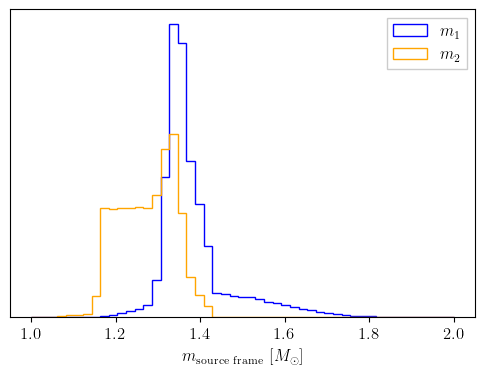

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))
bins = np.linspace(1, 2, 50)

ax.hist(df_narrow["mass_1_source"], color="blue", histtype="step", bins=bins, label="$m_1$")
ax.hist(df_narrow["mass_2_source"], color="orange", histtype="step", bins=bins, label="$m_2$")

ax.legend(framealpha=1, fancybox=False)
ax.set_yticks([])
ax.set_xlabel("$m_{\\mathrm{source\ frame}}$ [$M_\\odot$]")

Text(0.5, 0, '$m_{\\mathrm{source\\ frame}}$ [$M_\\odot$]')

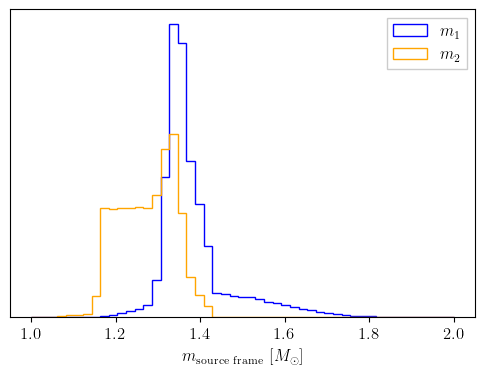

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))
bins = np.linspace(1, 2, 50)

ax.hist(df_narrow["mass_1_source"], color="blue", histtype="step", bins=bins, label="$m_1$")
ax.hist(df_narrow["mass_2_source"], color="orange", histtype="step", bins=bins, label="$m_2$")

ax.legend(framealpha=1, fancybox=False)
ax.set_yticks([])
ax.set_xlabel("$m_{\\mathrm{source\ frame}}$ [$M_\\odot$]")

(array([7.4063e+04, 8.6640e+03, 4.5950e+03, 1.9790e+03, 7.6900e+02,
        2.7700e+02, 1.0200e+02, 4.2000e+01, 1.0000e+01, 9.0000e+00]),
 array([0.        , 0.01424745, 0.0284949 , 0.04274235, 0.0569898 ,
        0.07123725, 0.08548471, 0.09973216, 0.11397961, 0.12822706,
        0.14247451]),
 <BarContainer object of 10 artists>)

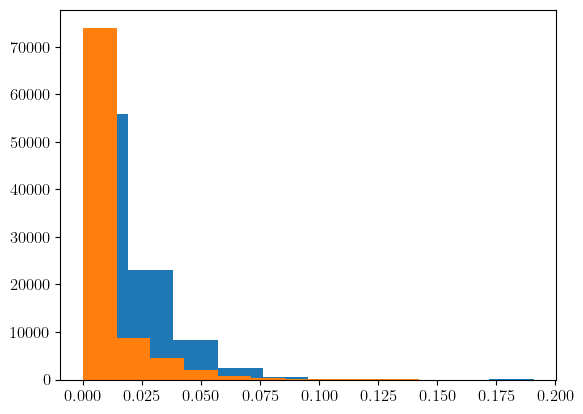

In [9]:
plt.hist(df_narrow_file["chi1_z"])
plt.hist(df_narrow_file["chi2_z"])

Text(0.5, 0, '$m_{\\mathrm{source\\ frame}}$ [$M_\\odot$]')

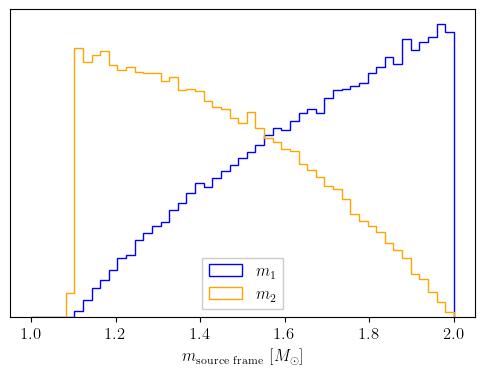

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))
bins = np.linspace(1, 2, 50)

ax.hist(df_wide["mass_1_source"], color="blue", histtype="step", bins=bins, label="$m_1$")
ax.hist(df_wide["mass_2_source"], color="orange", histtype="step", bins=bins, label="$m_2$")

ax.legend(framealpha=1, fancybox=False)
ax.set_yticks([])
ax.set_xlabel("$m_{\\mathrm{source\ frame}}$ [$M_\\odot$]")

Text(0.5, 0, '$m_{\\mathrm{source\\ frame}}$ [$M_\\odot$]')

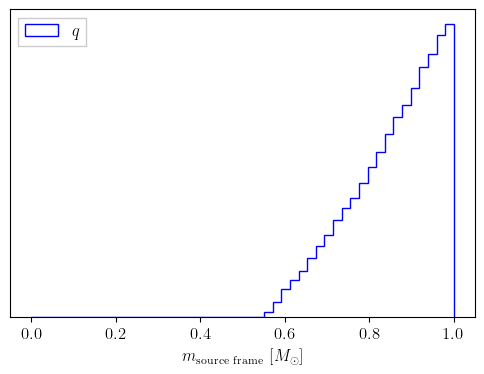

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))
bins = np.linspace(0, 1, 50)

ax.hist(df_wide["mass_2_source"] / df_wide["mass_1_source"], color="blue", histtype="step", bins=bins, label="$q$")

ax.legend(framealpha=1, fancybox=False)
ax.set_yticks([])
ax.set_xlabel("$m_{\\mathrm{source\ frame}}$ [$M_\\odot$]")

# GWToolbox

In [54]:
from astropy.cosmology import Planck18
import astropy.units as u
from astropy.time import Time

from gwtoolbox.tools_earth import set_cosmology, Tools


cosmo = set_cosmology(H0=Planck18.H0.value, Om0=Planck18.Om0, Tcmb=Planck18.Tcmb0.value)
m_mean = 1.35 # Msol
m_scale = 0.3# Msol
m_low = 1.1 # Msol
m_high = 2.1 # Msol
chi_sigma = 0.04
R0=50
tau=3

Toolset = Tools(detector_type='et',
                event_type='nsns',
                population='I',
                cosmos=cosmo,
                det_setup=None,
                new_theta=[R0, tau, m_mean, m_scale, m_low, m_high, chi_sigma]) # population parameters

Text(0.5, 0, 'Cosmic time [Gyr]')

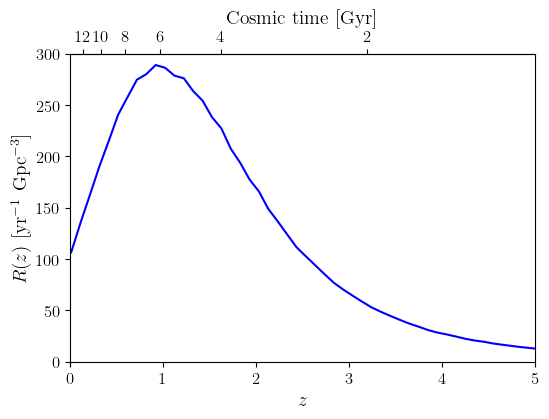

In [58]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))

ax.plot(Toolset.population_class.zs, Toolset.population_class.Rm, color="blue")

ax.set_xlim((0, 5))
ax.set_ylim((0, 300))
ax.set_ylabel("$R(z)$ [yr$^{-1}$ Gpc$^{-3}$]", fontsize=14)
ax.set_xlabel("$z$", fontsize=14)

z_grid = np.linspace(0, 6, 1000)
t_grid = Planck18.age(z_grid).to(u.Gyr).value

z_to_t = interp1d(z_grid, t_grid, bounds_error=False)
t_to_z = interp1d(t_grid[::-1], z_grid[::-1], bounds_error=False)

secax = ax.secondary_xaxis('top', functions=(z_to_t, t_to_z))
secax.set_xlabel("Cosmic time [Gyr]", fontsize=14)
